In [16]:
#Module 1: Python Foundations
# Data Loader for Customers.csv and Orders.csv

#1. Import Required Libraries - os is used for file handling and pandas is used to load and analyze CSV data.
import os
import pandas as pd


#2. Utility Function 1- Check whether file exists
#This function checks if the specified file is available in the current folder before trying to open it.


def file_exists(file_path):

    """
    Returns True if file exists, otherwise False.
    """
    return os.path.isfile(file_path)
print(file_exists("Capstone Customers.csv"))
print(file_exists("Capstone Orders.csv"))




#3. Utility Function 2 – Validate Dataset

#This function validates the dataset before processing by checking:

#Whether the dataset is empty,Missing value,Duplicate rows

def validate_data(df, dataset_name):
    """
    Validates the dataset before processing.
    """

    print(f"\nValidating {dataset_name}")

    if df.empty:
        print("Dataset is empty.")
        return False

    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()

    print("Missing Values :", missing)
    print("Duplicate Rows :", duplicates)

    return True

## Validate Customers dataset
#validate_data(customers, "Customers")

## Validate Orders dataset
#validate_data(orders, "Orders")

#4. Data Loader Function

#Checks whether the file exists,Reads the CSV file using Python file handling,Loads the data into Pandas ,Handles file errors


def load_data(file_name):

    try:

        if not file_exists(file_name):
            raise FileNotFoundError

        # Read using Python file handling
        with open(file_name, "r") as file:
            file.read()

        # Load into Pandas
        df = pd.read_csv(file_name)

        print(f"{file_name} loaded successfully.")

        return df

    except FileNotFoundError:
        print(f"{file_name} not found.")
        return None

    except pd.errors.EmptyDataError:
        print("The CSV file is empty.")
        return None

    except pd.errors.ParserError:
        print("The CSV file is corrupted.")
        return None

    except Exception as e:
        print("Unexpected Error:", e)
        return None

#5. Load the Datasets

#Load both CSV files using the load_data() function.

customers = load_data("Capstone Customers.csv")
orders = load_data("Capstone Orders.csv")


### Utility Function 3- Clean Column Names

def clean_column_names(df):
    """
    Removes extra spaces from column names.
    """
    df.columns = df.columns.str.strip()
    return df
customers = clean_column_names(customers)
orders = clean_column_names(orders)

## Validate Customers dataset
validate_data(customers, "Customers")

## Validate Orders dataset
validate_data(orders, "Orders")

#6.Display First Five Rows
print(customers.head())
print(orders.head())

#7.Display Dataset Shape - total rows and columns
print(customers.shape)
print(orders.shape)

#8.Display Dataset Information - Data types, non-null values,memory usage
customers.info()
orders.info()













True
True
Capstone Customers.csv loaded successfully.
Capstone Orders.csv loaded successfully.

Validating Customers
Missing Values : 8
Duplicate Rows : 3

Validating Orders
Missing Values : 8
Duplicate Rows : 5
   CustomerID  CustomerName Region    Segment    JoinDate
0           1    Ananya Das   East  Corporate  2023-08-19
1           2  Aarav Sharma  South   Consumer  2022-03-15
2           3  Saanvi Reddy  South   Consumer  2023-09-01
3           4  Aditya Reddy  South   Consumer  2022-02-09
4           5   Rahul Reddy  North   Consumer  2022-04-10
   OrderID  CustomerID   OrderDate     Category    Sales  Quantity  Discount  \
0     7001          39  2024-04-25  Electronics   702.14         1      0.20   
1     7002           3  2024-09-11  Electronics  1105.81         1      0.15   
2     7003          10  2024-12-06       Beauty    45.36         5      0.10   
3     7004           3  2024-12-01  Electronics   865.79         7      0.05   
4     7005          51  2024-04-19     C

In [37]:
### Module2: NumPy Analysis

1.#Convert the Sales and Profit columns into NumPy arrays.

import numpy as np

sales = orders["Sales"].to_numpy()
profit = orders["Profit"].to_numpy()

print("Sales Array:")
print(sales)

print("\nProfit Array:")
print(profit)

2.##Calculate mean, standard deviation, minimum, and maximum values.
print(np.isnan(sales).sum())
print(np.isnan(profit).sum())

#Use NumPy functions that ignore missing values:
print("\nSales Statistics")

print("Mean :", np.nanmean(sales))
print("Standard Deviation :", np.nanstd(sales))
print("Minimum :", np.nanmin(sales))
print("Maximum :", np.nanmax(sales))

print("\nProfit Statistics")

print("Mean :", np.nanmean(profit))
print("Standard Deviation :", np.nanstd(profit))
print("Minimum :", np.nanmin(profit))
print("Maximum :", np.nanmax(profit))

##3.Normalize the Sales values.

normalized_sales = (sales - np.nanmin(sales)) / (np.nanmax(sales) - np.nanmin(sales))

orders["Normalized Sales"] = normalized_sales

print(orders[["Sales", "Normalized Sales"]].head())

##4.Identify loss-making orders using np.where().

loss_orders = np.where(profit < 0)

print("Indexes of Loss Making Orders")
print(loss_orders)

print("\nLoss Making Orders")

print(orders.iloc[loss_orders])


Sales Array:
[ 702.14 1105.81   45.36  865.79  118.44  273.04  112.89  754.01  110.74
  241.88   27.54  374.14   55.17   75.84   85.55  121.68  636.93  122.48
   33.64   49.84   28.79   91.98   45.09  314.83  142.58   82.08   23.63
   68.78   59.71  162.91   69.59  288.11   92.52   30.38   88.05  194.74
    9.12  255.78  240.2  1134.44  683.6   145.99   55.85    9.86   91.77
   52.78   82.77   41.63  101.06  113.97  182.74   64.21   59.12   12.32
   72.37   40.83  853.18  113.9    65.66   78.26 1018.75  366.08  149.24
  147.48  370.18  159.32  213.25  336.19   64.76  540.67  237.7   111.81
  397.69   65.59  254.96  125.71   38.81  125.48   34.99  235.3  1119.24
  295.89  399.41  271.25   73.43  348.16   57.03  379.81   67.58    7.65
  139.53   27.91  129.14  306.06   47.19  721.47  191.56  390.29    7.42
  331.72  839.43   16.6    81.37   26.45  457.83   20.99  111.73   93.58
  370.77   77.16   40.85  110.37  125.66  533.97   35.69   93.34   75.24
  314.13    7.38   52.24  112.58  128.

In [37]:
##Module 3: Pandas Data Wrangling & EDA

#1. Merge Customers and Orders using CustomerID

import pandas as pd
# Load dataset
Customers = pd.read_csv("Capstone Customers.csv")
Orders = pd.read_csv("Capstone Orders.csv")


#2.Create common key if required
Customers["ID"] = range(50, len(Customers) + 50)


# Check column names
print("Customers Columns:")
print(Customers.columns)
print("\nOrders Columns:")
print(Orders.columns)


# Table 1: Customer/Location information
Capstone_Customer  = Customers[["CustomerID", "CustomerName", "Region", "Segment","JoinDate"]]
# Table 2: Ordes/Location information
Capstone_Orders = Orders[["OrderID","CustomerID", "OrderDate","Category", "Sales", "Quantity","Discount", "Profit"]]


# Merge tables
merged = pd.merge(Capstone_Customer, Capstone_Orders,
    on="CustomerID",
    how="inner"
)
print("\nMerged Dataset")
print(merged.head(10))


##3.Perform GroupBy Analysis with Multiple Aggregations
##Calculate total sales, average sales, total profit, and total quantity for each category.

group_summary = merged.groupby("Category").agg({
    "Sales": ["sum", "mean"],
    "Profit": ["sum", "mean"],
    "Quantity": "sum"
})
print("\ngroup_summary:")
print(group_summary)


4.##Create Pivot Tables.
##Create a Pivot Table showing total sales by Region and Category.

pivot_table = pd.pivot_table(
    merged,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

print(pivot_table)

#Add Calculated Columns
#(a) Profit Margin

merged["Profit Margin"] = (merged["Profit"] / merged["Sales"]) * 100

#(b) Profit per Unit

merged["Profit per Unit"] = (merged["Profit"]/merged["Quantity"])

#Display the new columns:
print(merged[["Sales", "Profit", "Quantity",
                 "Profit Margin", "Profit per Unit"]].head())

##6. Detect Outliers Using the IQR Method

Q1 = merged["Sales"].quantile(0.25)
Q3 = merged["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = merged[
    (merged["Sales"] < lower_limit) |
    (merged["Sales"] > upper_limit)
]

print("Number of Outliers:", len(outliers))
print(outliers)


##7.Generate a correlation matrix with a brief interpretation.

correlation = merged[["Sales", "Profit", "Quantity", "Discount"]].corr()

print(correlation)

##Interpretation
#Sales and Profit (0.606) have a moderate positive correlation. This indicates that as sales increase, profit generally tends to increase.
#Sales and Quantity (-0.058) have a very weak negative correlation. This means the number of items sold has almost no relationship with total sales in this dataset.
#Profit and Quantity (0.188) have a weak positive correlation. Selling more units has only a slight positive effect on profit

Customers Columns:
Index(['CustomerID', 'CustomerName', 'Region', 'Segment', 'JoinDate', 'ID'], dtype='object')

Orders Columns:
Index(['OrderID', 'CustomerID', 'OrderDate', 'Category', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

Merged Dataset
   CustomerID  CustomerName Region    Segment    JoinDate  OrderID  \
0           1    Ananya Das   East  Corporate  2023-08-19     7017   
1           1    Ananya Das   East  Corporate  2023-08-19     7202   
2           1    Ananya Das   East  Corporate  2023-08-19     7235   
3           1    Ananya Das   East  Corporate  2023-08-19     7286   
4           1    Ananya Das   East  Corporate  2023-08-19     7320   
5           1    Ananya Das   East  Corporate  2023-08-19     7379   
6           1    Ananya Das   East  Corporate  2023-08-19     7473   
7           1    Ananya Das   East  Corporate  2023-08-19     7491   
8           2  Aarav Sharma  South   Consumer  2022-03-15     7205   
9           2  Aarav Shar

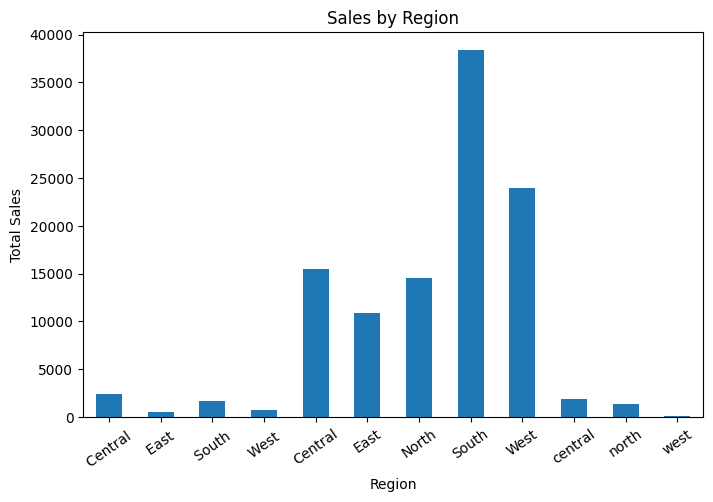

Regions with taller bars have higher sales performance,
It helps identify the best-performing and lowest-performing regions.


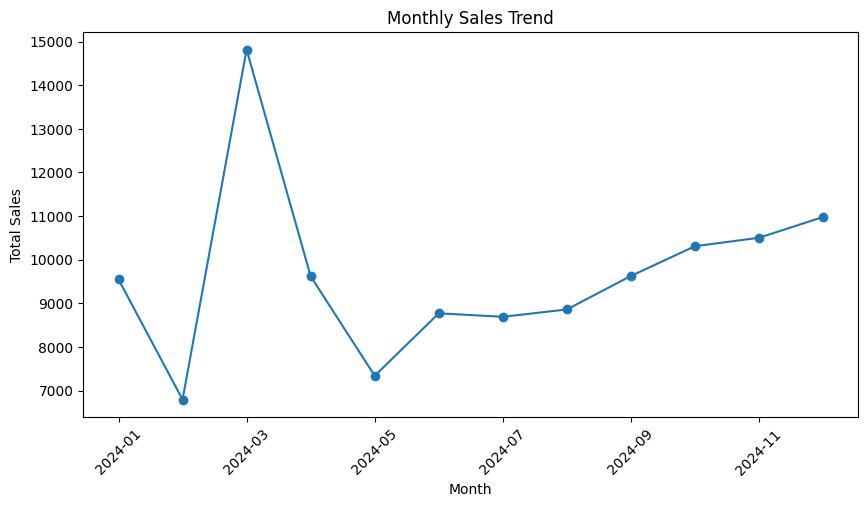

The line chart shows how sales change over time.
Peaks and dips help identify seasonal patterns or changes in demand.


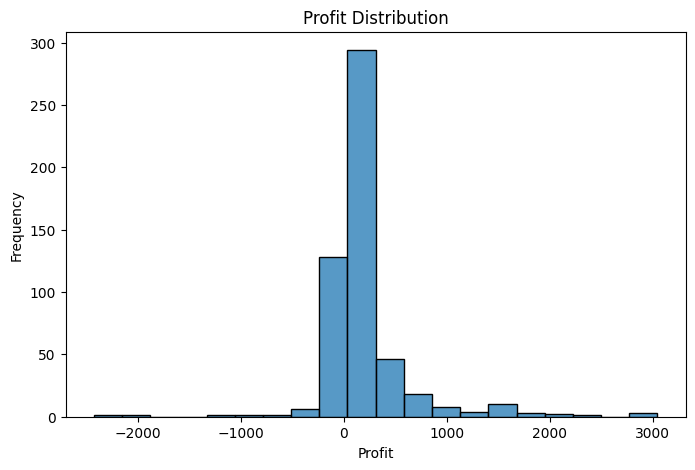

The histogram shows how profit values are distributed.
Most bars indicate the range where profits occur most frequently.


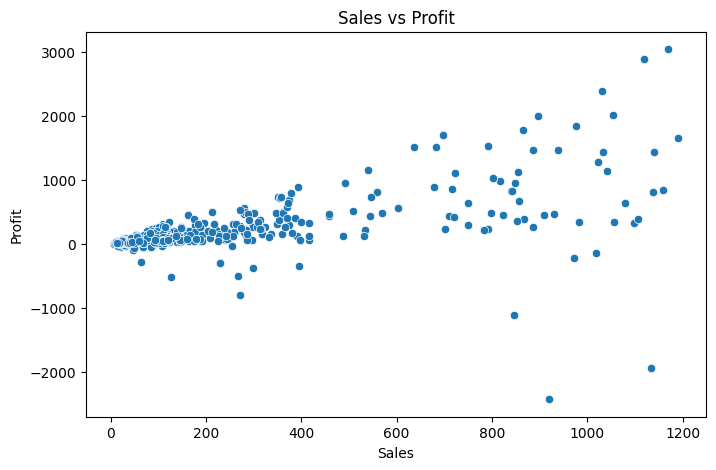

An upward pattern suggests that higher sales generally lead to higher profits.
Widely scattered points indicate greater variation in profitability across orders.


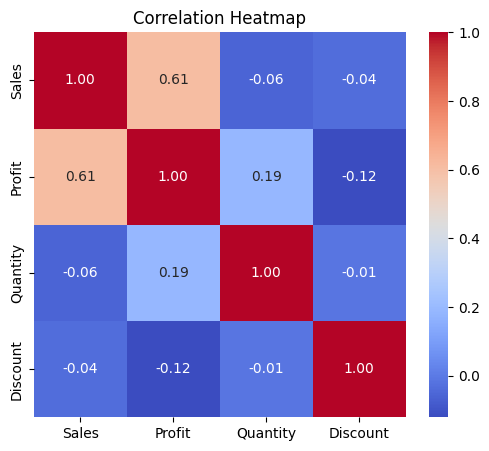

Values closer to 1 indicate a strong positive relationship.
Values closer to -1 indicate a strong negative relationship.
Values near 0 indicate little or no linear relationship.


In [49]:
#Module 4: Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

#1.Sales by Region (Bar Chart)
#Displays the total sales generated in each region.

sales_region = merged.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=35)
plt.show()
print("Regions with taller bars have higher sales performance,\nIt helps identify the best-performing and lowest-performing regions.")


#2. Monthly Sales Trend (Line Chart)
#Shows how sales change month by month.

# Convert OrderDate to datetime

merged["OrderDate"] = pd.to_datetime(merged["OrderDate"])

# Create Month column

merged["Month"] = merged["OrderDate"].dt.to_period("M").astype(str)

monthly_sales = merged.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()
print("The line chart shows how sales change over time.\nPeaks and dips help identify seasonal patterns or changes in demand.")

#3. Profit Distribution (Histogram)

#Shows how profit values are distributed.
plt.figure(figsize=(8,5))
sns.histplot(merged["Profit"], bins=20)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()
print("The histogram shows how profit values are distributed.\nMost bars indicate the range where profits occur most frequently.")

#4. Sales vs Profit (Scatter Plot)
#Shows the relationship between Sales and Profit.

plt.figure(figsize=(8,5))
sns.scatterplot(data=merged,
                x="Sales",
                y="Profit")

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()
print("An upward pattern suggests that higher sales generally lead to higher profits.\nWidely scattered points indicate greater variation in profitability across orders.")

#5. Correlation Heatmap
#Displays the correlation among numerical columns.

correlation = merged[["Sales","Profit","Quantity","Discount"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()
print("Values closer to 1 indicate a strong positive relationship.\nValues closer to -1 indicate a strong negative relationship.\nValues near 0 indicate little or no linear relationship.")

In [33]:

# Utility Function 2
# Display dataset information

def dataset_summary(df, dataset_name):
    """
    Prints dataset summary.
    """
    print("\n" + "=" * 50)
    print(f"Dataset : {dataset_name}")
    print("=" * 50)
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")
    print("\nColumn Names:")
    print(list(df.columns))
    print("\nData Types:")
    print(df.dtypes)
    print("=" * 50)
dataset_summary(customers, "Capstone Customers.csv")
dataset_summary(orders, "Capstone Orders.csv")


###numpy
##Solution 2

##Remove the missing values before creating the NumPy arrays:

sales = orders["Sales"].dropna().to_numpy()
profit = orders["Profit"].dropna().to_numpy()

#Then your original code will work:

np.mean(sales)
np.std(sales)
np.min(sales)
np.max(sales)


Dataset : Capstone Customers.csv
Rows    : 73
Columns : 5

Column Names:
['CustomerID', 'CustomerName', 'Region', 'Segment', 'JoinDate']

Data Types:
CustomerID       int64
CustomerName    object
Region          object
Segment         object
JoinDate        object
dtype: object

Dataset : Capstone Orders.csv
Rows    : 509
Columns : 8

Column Names:
['OrderID', 'CustomerID', 'OrderDate', 'Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
OrderID         int64
CustomerID      int64
OrderDate      object
Category       object
Sales         float64
Quantity        int64
Discount      float64
Profit        float64
dtype: object


np.float64(1196.17)

In [6]:
#3. Utility Function 2 – Validate Dataset

#This function validates the dataset before processing by checking:

#Whether the dataset is empty,Missing value,Duplicate rows

def validate_data(df, dataset_name):
    """
    Validates the dataset before processing.
    """

    print(f"\nValidating {dataset_name}")

    if df.empty:
        print("Dataset is empty.")
        return False

    missing = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()

    print("Missing Values :", missing)
    print("Duplicate Rows :", duplicates)

    return True
###def file_exists(file_name):
  ###def clean_column_names(df):
   ### def remove_duplicates(df):
###def count_missing_values(df):
 ##def validate_data(df, dataset_name):

